<a href="https://colab.research.google.com/github/MiksterBerlin/BRFSS_MH/blob/This%26That/Capstone_MH_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Depression Prediction Model**

The Behavioral Risk Factor Surveillance System (BRFSS) is an annual survey that is led by the Centers for Disease Control and Prevention (CDC) and applied in collaboration with the states and US territories.

BRFSS’s objective is to collect answers to a core of questions related to health risk behaviors, chronic diseases and conditions, access to health care, and use of preventive health services related to the leading causes of death and disability. States can select a number of elective modules to collect state-specific data on top of the annual core module. BRFSS conducts both landline and mobile phone-based surveys with individuals over the age of 18. General factors assessed by the BRFSS in 2021 included health status and healthy days, exercise, insufficient sleep, chronic health conditions, oral health, tobacco use, cancer screenings, and access to healthcare.

Survey data has been published annually by the [CDC](https://www.cdc.gov/) since 1984. You can find the [original dataset](https://www.cdc.gov/brfss/annual_data/annual_2021.html) as a ASCII format and past years data from [here](https://www.cdc.gov/brfss/annual_data/annual_data.htm).

The aim of this project is to build a model to predict mental health outcomes that could serve as a tool to prevent these outcomes from happening.
The data contains information about 6735 unique survey participants.



## **Importing of tools**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

#preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE

#Models
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import BaggingClassifier

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, RepeatedStratifiedKFold

#FeatureSelection
from sklearn.feature_selection import SelectKBest, f_classif

#Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay, roc_curve, auc, precision_score, recall_score
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.impute import SimpleImputer


# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Optional: Show full output that is generated
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = 'all'
#pd.set_option('display.max_columns', 500)

In [2]:
#Connect to personal Goodle drive to upload data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Uploading SAS datasets into Colab for processing

# Replace 'path/to/your/file.sas7bdat' with the actual path to your SAS file.
# If on Google Drive, it might look like '/content/drive/My Drive/your_folder/your_file.sas7bdat'
file_path = '/content/drive/My Drive/brfs_21p.sas7bdat'

try:
    df = pd.read_sas(file_path)
    print("SAS file successfully loaded into a pandas DataFrame.")
    print(df.head()) # Display the first few rows of the DataFrame
except UnicodeDecodeError:
    print("Encoding error detected. Attempting with Latin-1 encoding.")
    df = pd.read_sas(file_path, encoding='latin-1')
    print("SAS file successfully loaded with Latin-1 encoding.")
    print(df.head())
except FileNotFoundError:
    print(f"Error: File not found at {file_path}. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

SAS file successfully loaded into a pandas DataFrame.
   _STATE  _GEOSTR  _DENSTR2    REPNUM  REPDEPTH  FMONTH         DATE  CP_MN  \
0     6.0    206.0       2.0  123226.0       1.0    12.0  b'01042022'  b'01'   
1     6.0    206.0       1.0  123850.0      24.0    12.0  b'01042022'  b'01'   
2     6.0    202.0       2.0  123932.0      23.0    12.0  b'01042022'  b'01'   
3     6.0    206.0       2.0  123952.0      18.0    12.0  b'01062022'  b'01'   
4     6.0    202.0       1.0  124206.0       7.0    12.0  b'01052022'  b'01'   

   CP_DY    CP_YR  ...  PKREASON12_4  PKREASON12_5  PKREASON12_6  \
0  b'04'  b'2022'  ...           0.0           0.0           0.0   
1  b'04'  b'2022'  ...           0.0           0.0           0.0   
2  b'04'  b'2022'  ...           0.0           0.0           0.0   
3  b'06'  b'2022'  ...           0.0           0.0           0.0   
4  b'05'  b'2022'  ...           0.0           0.0           0.0   

   PKREASON12_7  _AGEG  _AGEGC  _RACEGR  _RACEG  _POVSTD

## **Reading Data and Selecting The Variables**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6735 entries, 0 to 6734
Columns: 514 entries, _STATE to SHMHWHERE2TXT
dtypes: float64(498), object(16)
memory usage: 26.4+ MB


In [5]:
df.describe()

,_STATE,_GEOSTR,_DENSTR2,REPNUM,REPDEPTH,FMONTH,_PSU,NRECSEL,NRECSTR,NUMADULT,...,PKREASON12_3,PKREASON12_4,PKREASON12_5,PKREASON12_6,PKREASON12_7,_AGEG,_AGEGC,_RACEGR,_RACEG,_POVSTD
count,6735.0,6735.000000,6735.000000,6735.000000,6735.000000,6735.000000,6.735000e+03,6735.000000,6.735000e+03,6735.000000,...,6735.000000,6735.000000,6735.000000,6735.000000,6735.000000,6654.000000,6654.000000,6735.000000,6735.000000,6735.000000
mean,6.0,185.916110,1.339866,51354.913586,15.549369,5.106904,2.021003e+09,15545.861173,1.007198e+07,2.420787,...,0.008018,0.018708,0.000445,0.001336,0.012324,3.938082,1.582807,2.336600,1.753081,2.223311
std,0.0,38.361759,0.539369,25596.233485,8.634128,2.550268,1.944371e+03,7018.130020,5.425220e+06,2.877808,...,0.089189,0.135503,0.021102,0.036534,0.110334,1.705796,0.493132,1.635837,1.375049,2.441904
min,6.0,101.000000,1.000000,10001.000000,1.000000,1.000000,2.021000e+09,3745.000000,5.078990e+05,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,6.0,201.000000,1.000000,40013.000000,8.000000,4.000000,2.021002e+09,8549.000000,5.927339e+06,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000,1.000000,0.000000
50%,6.0,203.000000,1.000000,50283.000000,16.000000,5.000000,2.021003e+09,15689.000000,1.250960e+07,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2.000000,2.000000,2.000000,1.000000
75%,6.0,205.000000,2.000000,70410.000000,23.000000,7.000000,2.021005e+09,19895.000000,1.289920e+07,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2.000000,3.000000,2.000000,5.000000
max,6.0,206.000000,9.000000,124206.000000,30.000000,12.000000,2.021007e+09,25498.000000,1.715263e+07,99.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,2.000000,9.000000,9.000000,6.000000


In [6]:
# Selecting Variables that have either shown to be associated with Depression or might play a role for mental health outcomes

df_selected= df[['DEPRESS1', '_LLCPWT2', 'POORHLTH', 'HEART2',    'TYPPLAN1', 'EXERANY1',  'ANGINA', 'STROKE2', 'ASTHEVE3',     'SKCANC',       'OTHCANC',      'COPDEVER',    'KIDNEY',       'DIABCOR3',   'EDUCAC', 'MILITAR2',  'EMPLOY2',  'PREGNANT'   ,'DEAF',        'BLIND' ,'REMEM2',      'DIFFWALK',     'DIFDRES2',     'DIFFERND',  'CAREGIV6', 'HAVEGUN2', 'TRNSGNDR',     '_REGION',   '_IMPMRTL',     '_IMPHOME',   '_RFHLTH',      '_PHYS14D',     '_MENT14D',  '_RFCHOL3',   '_HLTHPLN', '_TOTINDA', '_RFHYPE6',     '_CHOLCH3' , '_SEX','_AGE_G',  '_IMPRACE',    '_BMI5CAT', '_CHLDCNT',      '_INCOMG1' , '_RFSMOK3',   '_RFBING5', '_FRTLT1A',  '_VEGLT1A'  , 'HHSIZE',       'COUNTY1', '_URBSTAT' , 'SXORIEN2', 'GAMBLE',  'MARIJANA1' ,  'HEREVER', 'FENTEVER', 'STIMEVER',  '_POVSTD', 'PCEDIFF',  'PCETALK' , 'PCESAFE',  'PCETRAD',  'PCESUPP',  'PCESCHL', 'PCEINTR', 'ACECARE' , 'ACEDEPRS' , 'ACEALC'  ,'ACEDRGS' , 'ACEJAIL2' , 'ACEDVRCE',  'ACEADLHT' ,'ACEHTKDS' , 'ACEINSLT' , 'ACELOVE' , 'ACETCHU'  ,'TSSSXEVER', 'TSSSXYR17']]

In [7]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6735 entries, 0 to 6734
Data columns (total 78 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   DEPRESS1   6735 non-null   float64
 1   _LLCPWT2   6735 non-null   float64
 2   POORHLTH   3642 non-null   float64
 3   HEART2     6735 non-null   float64
 4   TYPPLAN1   6735 non-null   float64
 5   EXERANY1   6735 non-null   float64
 6   ANGINA     6735 non-null   float64
 7   STROKE2    6735 non-null   float64
 8   ASTHEVE3   6735 non-null   float64
 9   SKCANC     6735 non-null   float64
 10  OTHCANC    6735 non-null   float64
 11  COPDEVER   6735 non-null   float64
 12  KIDNEY     6735 non-null   float64
 13  DIABCOR3   6735 non-null   float64
 14  EDUCAC     6735 non-null   float64
 15  MILITAR2   6719 non-null   float64
 16  EMPLOY2    6686 non-null   float64
 17  PREGNANT   1463 non-null   float64
 18  DEAF       6493 non-null   float64
 19  BLIND      6468 non-null   float64
 20  REMEM2  

**Looking for Missing Values and Handling Them**

Since missing values are very few compared to the size of the data, there is no problem in deleting them.

In [8]:
# check for missing values in dataset
df_selected.isna().sum()


,0
DEPRESS1,0
_LLCPWT2,0
POORHLTH,3093
HEART2,0
TYPPLAN1,0
...,...
ACEINSLT,4372
ACELOVE,4374
ACETCHU,4376
TSSSXEVER,4357


## **Data Cleaning and Exploration**

In [9]:
#Exchange missing values with -1
df = df_selected.replace([np.nan], -1)

In [10]:
#Exchange unknown or no answer values with -1
df2 = df.replace([99.0, 88.0, 77.0, 888.0, 777.0, 999.0],-1)
print(df2)

      DEPRESS1     _LLCPWT2  POORHLTH  HEART2  TYPPLAN1  EXERANY1  ANGINA  \
0          2.0  4374.862450      -1.0     2.0       3.0       1.0     2.0   
1          2.0  4374.862450      -1.0     2.0      10.0       1.0     2.0   
2          1.0  3579.102106      -1.0     2.0      -1.0       1.0     2.0   
3          2.0  4374.862450      -1.0     2.0       1.0       1.0     2.0   
4          2.0  3579.102106      -1.0     2.0       1.0       1.0     2.0   
...        ...          ...       ...     ...       ...       ...     ...   
6730       2.0  4374.862450      -1.0     2.0       1.0       2.0     2.0   
6731       2.0  4374.862450      -1.0     2.0       1.0       1.0     2.0   
6732       2.0  4374.862450      -1.0     2.0       5.0       1.0     2.0   
6733       2.0  4374.862450       4.0     2.0       1.0       1.0     2.0   
6734       1.0  4374.862450      30.0     2.0       1.0       2.0     2.0   

      STROKE2  ASTHEVE3  SKCANC  ...  ACEDRGS  ACEJAIL2  ACEDVRCE  ACEADLHT

**Reocoding a few of the variables Using the BRFSS 2021 Codebook**
https://www.cdc.gov/brfss/annual_data/2021/pdf/codebook21_llcp-v2-508.pdf

**SEXVAR**

SEXVAR column contains participants gender information.
1 means male
2 means female.
For better reading, the column renamed as 'Gender'.

<Axes: xlabel='Gender', ylabel='count'>

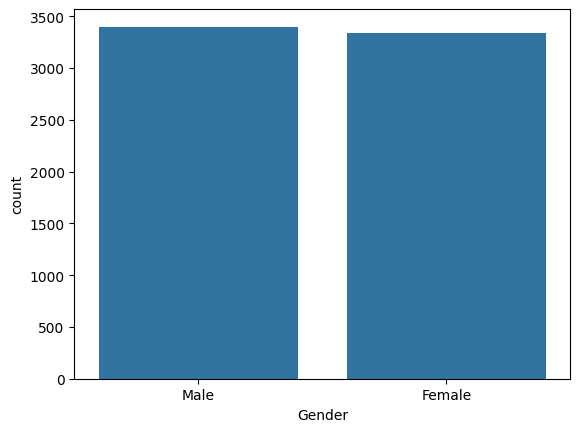

In [11]:
df2['_SEX'].value_counts()
df2 = df2.rename(columns={"_SEX":"Gender"})
df2['Gender'] = df2['Gender'].replace({
    1: 'Male',
    2: 'Female',
})

sns.countplot(x='Gender', data=df2)

**\_IMPRACE**

The \_IMPRACE column contains participants race information.

* 1 means White
* 2 means Black
* 3 means Asian
* 4 means American Indian/Alaskan Native
* 5 means Hispanic
* 6 means Other race

For better reading, the column renamed as 'Race'.

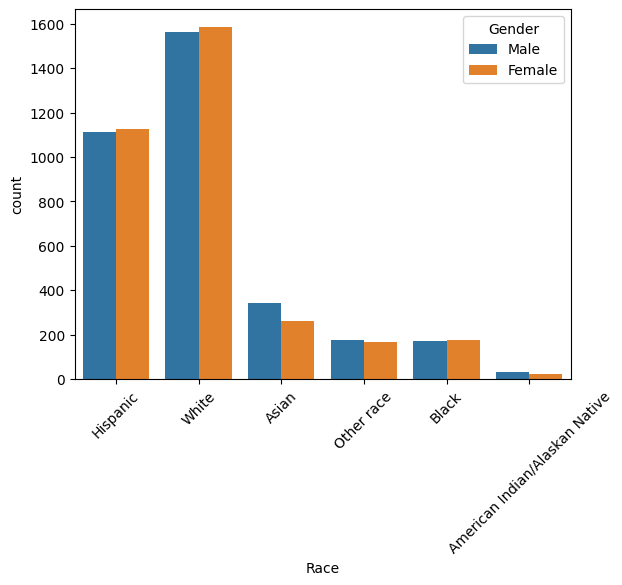

In [12]:
df2['_IMPRACE'].value_counts()
df2 = df2.rename(columns={'_IMPRACE':'Race'})

df2['Race'] = df2['Race'].replace({
    1: 'White',
    2: 'Black',
    3: 'Asian',
    4: 'American Indian/Alaskan Native',
    5: 'Hispanic',
    6: 'Other race'
})

sns.countplot(x='Race', hue='Gender', data=df2)
plt.xticks(rotation=45)

plt.show()

**_AGE_G**

The _AGE_G column contains information about the age of the participants.


* 1 means 18 to 24
* 2 means 25 to 34
* 3 means 35 to 44
* 4 means 45 to 54
* 5 means 55 to 64
* 6 means over 65



<Axes: xlabel='Age Groups', ylabel='count'>

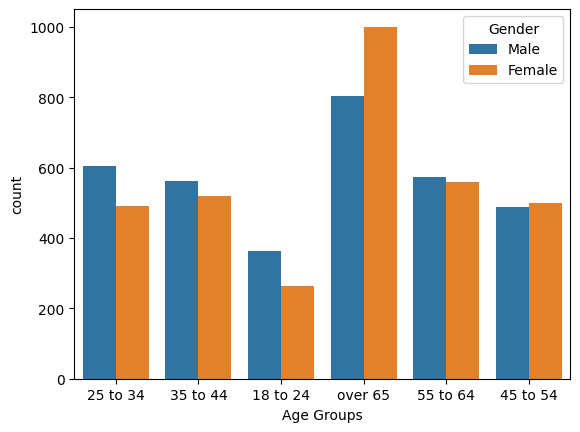

In [13]:
df2['_AGE_G'].value_counts()
df2 = df2.rename(columns={'_AGE_G':"Age Groups"})

df2['Age Groups'] = df2['Age Groups'].replace({
    1: '18 to 24',
    2: '25 to 34',
    3: '35 to 44',
    4: '45 to 54',
    5: '55 to 64',
    6: 'over 65'
})

sns.countplot(x='Age Groups', hue='Gender', data=df2)

# **This is a good example for sampling bias in this survey. This is exactly why one should include sample weights in the models. Otherwise this would influence the outcome of the analysis.**


**_HLTHPLN**

<Axes: xlabel='Health Insurance', ylabel='count'>

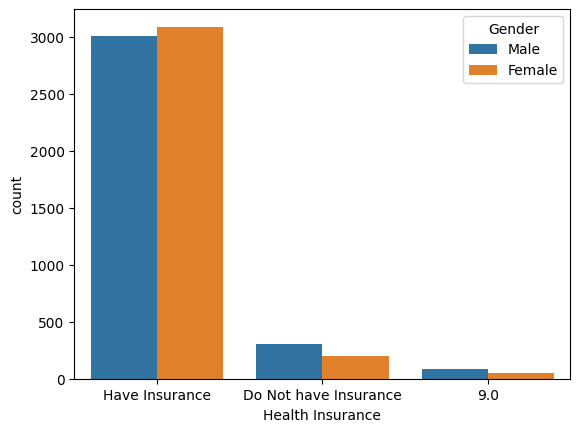

In [14]:
df2['_HLTHPLN'].value_counts()
df2 = df2.rename(columns={'_HLTHPLN': "Health Insurance"})

df2['Health Insurance'] = df2['Health Insurance'].replace({
    1: 'Have Insurance',
    2: 'Do Not have Insurance',
})

sns.countplot(x='Health Insurance', hue='Gender', data=df2)

**EMPLOY2**

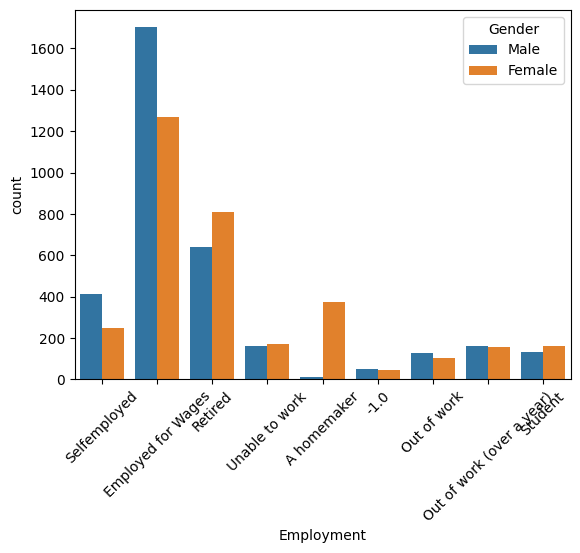

In [15]:
df2['EMPLOY2'].value_counts()
df2 = df2.rename(columns={'EMPLOY2': "Employment"})
df2['Employment'] = df2['Employment'].replace({
    1: 'Employed for Wages',
    2: 'Selfemployed',
    3: 'Out of work (over a year)',
    4: 'Out of work',
    5: 'A homemaker',
    6: 'Student',
    7: 'Retired' ,
    8: 'Unable to work',
    9: 'Refused'
})

sns.countplot(x='Employment', hue='Gender', data=df2)

plt.xticks(rotation=45)

plt.show()

SXORIEN2

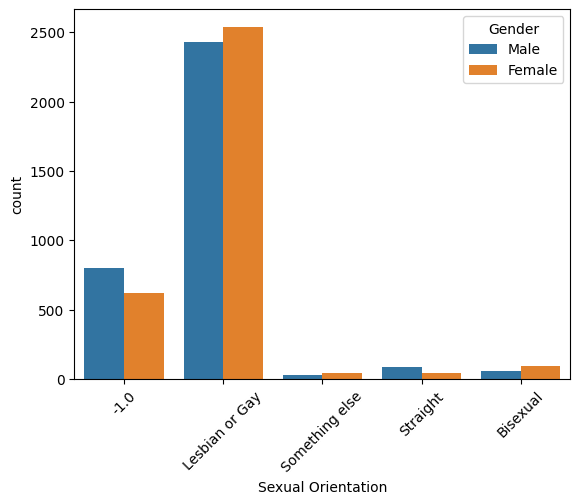

In [16]:
#Sexual Orientation
df2['SXORIEN2'].value_counts()
df2 = df2.rename(columns={'SXORIEN2': "Sexual Orientation"})
df2['Sexual Orientation'] = df2['Sexual Orientation'].replace({
    1: 'Lesbian or Gay',
    2: 'Straight',
    3: 'Bisexual',
    4: 'Something else'})

sns.countplot(x='Sexual Orientation', hue='Gender', data=df2)

plt.xticks(rotation=45)

plt.show()

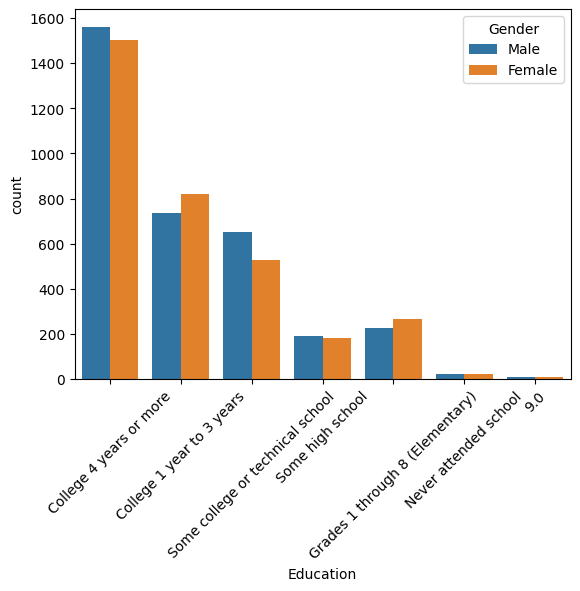

In [17]:
df2['EDUCAC'].value_counts()
df2 = df2.rename(columns={'EDUCAC': "Education"})
#Education Level
df2['Education'] = df2['Education'].replace({
    1.0: 'Never attended school',
    2.0: 'Grades 1 through 8 (Elementary)',
    3.0: 'Some high school',
    4.0: 'Some college or technical school',
    5.0: 'College 1 year to 3 years',
    6.0: 'College 4 years or more'
})

sns.countplot(x='Education', hue='Gender', data=df2)

plt.xticks(rotation=45)

plt.show()

# **Target Variable "Ever Diagnosed with Depression" DEPRESS1**

The 'Depress1' column contains participants general health information.

* 1 Yes
* 2 No
* -1 missing

For better reading, the column renamed as 'Depression'.

<Axes: xlabel='Depression', ylabel='count'>

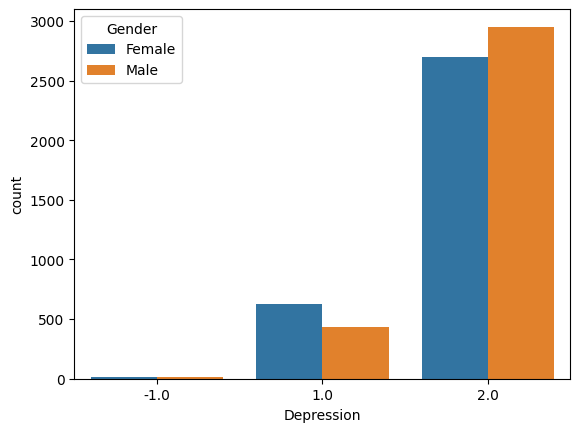

In [18]:
df2['DEPRESS1'].value_counts()
df2.drop(df2[df2['DEPRESS1'] == 99.0].index, inplace = True)
df2.drop(df2[df2['DEPRESS1'] == 77.0].index, inplace = True)
df2 = df2.rename(columns={'DEPRESS1':'Depression'})
sns.countplot(x='Depression', hue='Gender', data=df2)

In [19]:
#Subset the dataset to only include 1 = 'Yes' or 2= 'No' and exclude any other options

subset= df2[df2['Depression'].isin([1,2])]
subset.head()

,Depression,_LLCPWT2,POORHLTH,HEART2,TYPPLAN1,EXERANY1,ANGINA,STROKE2,ASTHEVE3,SKCANC,...,ACEDRGS,ACEJAIL2,ACEDVRCE,ACEADLHT,ACEHTKDS,ACEINSLT,ACELOVE,ACETCHU,TSSSXEVER,TSSSXYR17
0,2.0,4374.862450,-1.0,2.0,3.0,1.0,2.0,2.0,2.0,2.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,2.0,4374.862450,-1.0,2.0,10.0,1.0,2.0,2.0,2.0,2.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,1.0,3579.102106,-1.0,2.0,-1.0,1.0,2.0,2.0,2.0,2.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,2.0,4374.862450,-1.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
4,2.0,3579.102106,-1.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


## **Preprocessing and Transforming the data**

In [20]:
#separate cathegorical and nummerical variables for processing
cathegorical_features = ['HEART2',    'TYPPLAN1', 'EXERANY1',  'ANGINA', 'STROKE2', 'ASTHEVE3', 'SKCANC',  'OTHCANC', 'COPDEVER', 'KIDNEY', 'DIABCOR3', 'Education', 'MILITAR2',  'Employment',  'PREGNANT','DEAF', 'BLIND' ,'REMEM2',      'DIFFWALK',     'DIFDRES2',     'DIFFERND',  'CAREGIV6', 'HAVEGUN2', 'TRNSGNDR',     '_REGION',   '_IMPMRTL',     '_IMPHOME',   '_RFHLTH',      '_PHYS14D',     '_MENT14D',  '_RFCHOL3',   'Health Insurance', '_TOTINDA', '_RFHYPE6',     '_CHOLCH3' , 'Gender', 'Age Groups' ,  'Race',    '_BMI5CAT', '_CHLDCNT',      '_INCOMG1' , '_RFSMOK3',   '_RFBING5', '_FRTLT1A',  '_VEGLT1A'  , 'HHSIZE',       'COUNTY1', '_URBSTAT' , 'Sexual Orientation', 'GAMBLE',  'MARIJANA1' ,  'HEREVER', 'FENTEVER', 'STIMEVER',  '_POVSTD', 'PCEDIFF',  'PCETALK' , 'PCESAFE',  'PCETRAD',  'PCESUPP',  'PCESCHL', 'PCEINTR', 'ACECARE' , 'ACEDEPRS' , 'ACEALC'  ,'ACEDRGS' , 'ACEJAIL2' , 'ACEDVRCE',  'ACEADLHT' ,'ACEHTKDS' , 'ACEINSLT' , 'ACELOVE' , 'ACETCHU'  ,'TSSSXEVER', 'TSSSXYR17']
nummeric_features = ['POORHLTH','HHSIZE', ]
survey_weights = ['_LLCPWT2']

In [21]:
# Select only the numeric columns for the pivot table
numeric_df = subset[nummeric_features + ['Depression']]

# Create the pivot table using only the numeric features as values
table1 = pd.pivot_table(data=numeric_df, index=['Depression'])
table1

,HHSIZE,POORHLTH
Depression,,
1.0,2.265537,7.623352
2.0,2.397450,1.277187


In [31]:
# drop target variable and survey weight from the X dataset
X = subset.drop(columns=['Depression', '_LLCPWT2'])
y = subset['Depression']

# Extract the survey weights
survey_weights = df['_LLCPWT2']

In [32]:
#recode variables as string to preprocess without an error as some variables were recoded and some are still numbers
X[cathegorical_features] = X[cathegorical_features].astype("string")

In [33]:
#Categorical features will be transformed using OneHotEncoder and nummeric features with the StandardScaler

preprocessor = make_column_transformer(
    (OneHotEncoder(dtype=np.float64), cathegorical_features),
    (StandardScaler() , nummeric_features)
)

In [34]:
pipeline = make_pipeline(preprocessor)

In [35]:
#Transform the dataset
X_transformed = pipeline.fit_transform(X)

print(X_transformed.shape)

(6708, 377)


## **Basic screening of data**

1**.   Screening for Variables that have a high and statistically significant correltation with the target Variable**




In [36]:
#Correlation matix to reduce features for analysis for first model
from scipy.stats import pearsonr

# For simplicity, assuming it's a dense NumPy array or can be converted.
if not isinstance(X_transformed, np.ndarray):
    # Check if it's a sparse matrix before converting
    if hasattr(X_transformed, 'toarray'):
        Xtr = X_transformed.toarray() # Convert sparse matrix to dense if necessary
    # If it's neither ndarray nor sparse, print a warning or handle appropriately
    else:
        print("Warning: X is not a NumPy array or sparse matrix. Correlation might not be calculated correctly.")
        Xtr = X_transformed # Keep as is if not sparse and not ndarray (unlikely but safe)


# Ensure y is a NumPy array for consistent indexing, though pandas Series also works
if isinstance(y, pd.Series):
    y = y.values

# **Encode the target variable y to numerical values if necesarry, in case you use the BRFSS format SAS program first**
# Map 'yes' to 1 and 'no' to 2
y_encoded = np.where(y == 1.0, 1, 2) # Assuming 1.0 is the positive class

# Iterate through each column (feature) in X and calculate the correlation with y
# Assuming X has shape (n_samples, n_features)
n_features = Xtr.shape[1]

# Store results to sort later
correlation_results = []



print("Pearson Correlation Coefficients and p-values for each feature:")
for i in range(n_features):
    # Select the i-th column (feature) from X_transformed1
    feature_column = Xtr[:, i]

    # Calculate Pearson correlation between the feature and the target variable
    # Use the encoded target variable
    # Check for constant features or features with zero variance before calculating correlation
    if np.std(feature_column) == 0:
        corr_coef = 0.0
        p_value = 1.0
    else:
        corr_coef, p_value = pearsonr(feature_column, y_encoded)


    # Store the results along with the feature index (and potentially name)
    correlation_results.append({'feature_index': i, 'correlation': corr_coef, 'p_value': p_value})


# Let's sort by p-value in ascending order to find the most significant features first (p<0.05)
sorted_results_by_pvalue = sorted(correlation_results, key=lambda x: x['p_value'])

# Sort by absolute correlation to see the strongest relationships regardless of direction:
sorted_results_by_abs_corr = sorted(correlation_results, key=lambda x: abs(x['correlation']), reverse=True)

print("\nSorted Pearson Correlation Coefficients and p-values (by absolute correlation, descending):")
# Print the sorted results
for result in sorted_results_by_abs_corr:
     feature_index = result['feature_index']
     corr_coef = result['correlation']
     p_value = result['p_value']
     # Removed attempt to use undefined 'feature_name'
     print(f"  'Feature {feature_index}': Correlation = {corr_coef:.4f}, p-value = {p_value:.4f}")


Pearson Correlation Coefficients and p-values for each feature:

Sorted Pearson Correlation Coefficients and p-values (by absolute correlation, descending):
  'Feature 121': Correlation = -0.3625, p-value = 0.0000
  'Feature 119': Correlation = 0.3236, p-value = 0.0000
  'Feature 72': Correlation = -0.3152, p-value = 0.0000
  'Feature 375': Correlation = -0.3061, p-value = 0.0000
  'Feature 73': Correlation = 0.2613, p-value = 0.0000
  'Feature 81': Correlation = -0.2283, p-value = 0.0000
  'Feature 115': Correlation = 0.1992, p-value = 0.0000
  'Feature 61': Correlation = -0.1649, p-value = 0.0000
  'Feature 75': Correlation = -0.1624, p-value = 0.0000
  'Feature 112': Correlation = 0.1575, p-value = 0.0000
  'Feature 113': Correlation = -0.1565, p-value = 0.0000
  'Feature 82': Correlation = 0.1530, p-value = 0.0000
  'Feature 117': Correlation = -0.1463, p-value = 0.0000
  'Feature 370': Correlation = -0.1447, p-value = 0.0000
  'Feature 372': Correlation = 0.1438, p-value = 0.0000


In [37]:
# Fetch the original feature names from the pipeline
original_feature_names = pipeline.named_steps['columntransformer'].get_feature_names_out()

# Get the indices of features to keep based on the correlation results
# These indices are relative to the original 294 features
valid_feature_indices_original = [result['feature_index'] for result in correlation_results if result['p_value'] <= 0.05 and result['feature_index'] < X_transformed.shape[1]]

# Select columns from the sparse matrix using integer indexing
# The operation correctly use the indices relative to the X_transformed matrices
X = X_transformed[:, valid_feature_indices_original]

# Update feature_names to reflect the names of the selected features
feature_names2 = original_feature_names[valid_feature_indices_original]


print(f"Original number of features: {X_transformed.shape[1]}")
print(f"Number of features to drop: {X_transformed.shape[1] - len(valid_feature_indices_original)}")
print(f"Number of features after dropping: {X.shape[1]}")
print(f"Selected feature names: {list(feature_names2)}...")

Original number of features: 377
Number of features to drop: 189
Number of features after dropping: 188
Selected feature names: ['onehotencoder__HEART2_1.0', 'onehotencoder__HEART2_2.0', 'onehotencoder__TYPPLAN1_10.0', 'onehotencoder__TYPPLAN1_6.0', 'onehotencoder__TYPPLAN1_7.0', 'onehotencoder__EXERANY1_1.0', 'onehotencoder__EXERANY1_2.0', 'onehotencoder__ANGINA_1.0', 'onehotencoder__ANGINA_2.0', 'onehotencoder__STROKE2_-1.0', 'onehotencoder__STROKE2_1.0', 'onehotencoder__STROKE2_2.0', 'onehotencoder__ASTHEVE3_-1.0', 'onehotencoder__ASTHEVE3_1.0', 'onehotencoder__ASTHEVE3_2.0', 'onehotencoder__OTHCANC_-1.0', 'onehotencoder__OTHCANC_1.0', 'onehotencoder__OTHCANC_2.0', 'onehotencoder__COPDEVER_1.0', 'onehotencoder__COPDEVER_2.0', 'onehotencoder__KIDNEY_1.0', 'onehotencoder__KIDNEY_2.0', 'onehotencoder__DIABCOR3_1.0', 'onehotencoder__DIABCOR3_3.0', 'onehotencoder__DIABCOR3_4.0', 'onehotencoder__Education_College 1 year to 3 years', 'onehotencoder__Education_College 4 years or more', 'one

**2.   Oversampling of the dataset to balance the target variable**

In [38]:
from imblearn.over_sampling import SMOTE
smote1=SMOTE(sampling_strategy='minority')
XR, yR=smote1.fit_resample(X, y)

# Replicate survey weights for the oversampled data
# This assumes that SMOTE adds samples to the end of the original data
# and that the order of original samples is preserved.
# You need to make sure 'X' and 'y' passed to smote1.fit_resample
# contain the original samples in the same order as 'survey_weights'.
original_samples_count = len(y)
oversampled_samples_count = len(yR)

# Create an array to hold the oversampled weights
oversampled_survey_weights = np.zeros(oversampled_samples_count)

# Copy original weights
oversampled_survey_weights[:original_samples_count] = survey_weights[:original_samples_count]

# For synthetic samples (added by SMOTE), you might assign weights
# based on the original minority samples they were generated from.
# A simple approach is to assign the average weight of the minority class, or 1.0.
# For this fix, we'll assume synthetic samples are added after original ones.
oversampled_survey_weights[original_samples_count:] = 1.0 #will re-evaluate later

# Normalize these oversampled weights later if needed for models.
survey_weights = oversampled_survey_weights

**3. Dropping OneHotEncoder Variables that don't contain any usefull data**

In [39]:
# Identify one-hot encoded features ending in -1.0, 0.0 or 9.0 from the feature names as they don't contain usefull data
features_to_drop = [
    feature for feature in feature_names2 if feature.endswith('_-1.0') or feature.endswith('_9.0') or feature.endswith('_0.0')
]

# Get the indices of these features in the XR dataset
features_to_keep_indices = [
    i for i, feature in enumerate(feature_names2)
    if feature not in features_to_drop
]

# Select the columns to keep from the XR dataset
XR_further_reduced = XR[:, features_to_keep_indices]

# Update feature names to reflect the further reduced dataset
feature_names_further_reduced_XR = [feature_names2[i] for i in features_to_keep_indices]

print(f"Original number of features in XR: {XR.shape[1]}")
print(f"Number of features dropped: {len(features_to_drop)}")
print(f"Number of features after dropping: {XR_further_reduced.shape[1]}")
print(f"Features dropped: {features_to_drop}")

Original number of features in XR: 188
Number of features dropped: 19
Number of features after dropping: 169
Features dropped: ['onehotencoder__STROKE2_-1.0', 'onehotencoder__ASTHEVE3_-1.0', 'onehotencoder__OTHCANC_-1.0', 'onehotencoder__PREGNANT_-1.0', 'onehotencoder__BLIND_-1.0', 'onehotencoder__DIFDRES2_-1.0', 'onehotencoder__DIFFERND_-1.0', 'onehotencoder__TRNSGNDR_-1.0', 'onehotencoder___RFCHOL3_-1.0', 'onehotencoder___INCOMG1_9.0', 'onehotencoder___RFSMOK3_9.0', 'onehotencoder___RFBING5_9.0', 'onehotencoder___FRTLT1A_9.0', 'onehotencoder___VEGLT1A_9.0', 'onehotencoder__COUNTY1_-1.0', 'onehotencoder__Sexual Orientation_-1.0', 'onehotencoder__MARIJANA1_-1.0', 'onehotencoder___POVSTD_0.0', 'onehotencoder__TSSSXYR17_-1.0']


In [40]:
XR_further_reduced.shape

(11292, 169)

**4. Checking for Intercorrelations in the dataset**

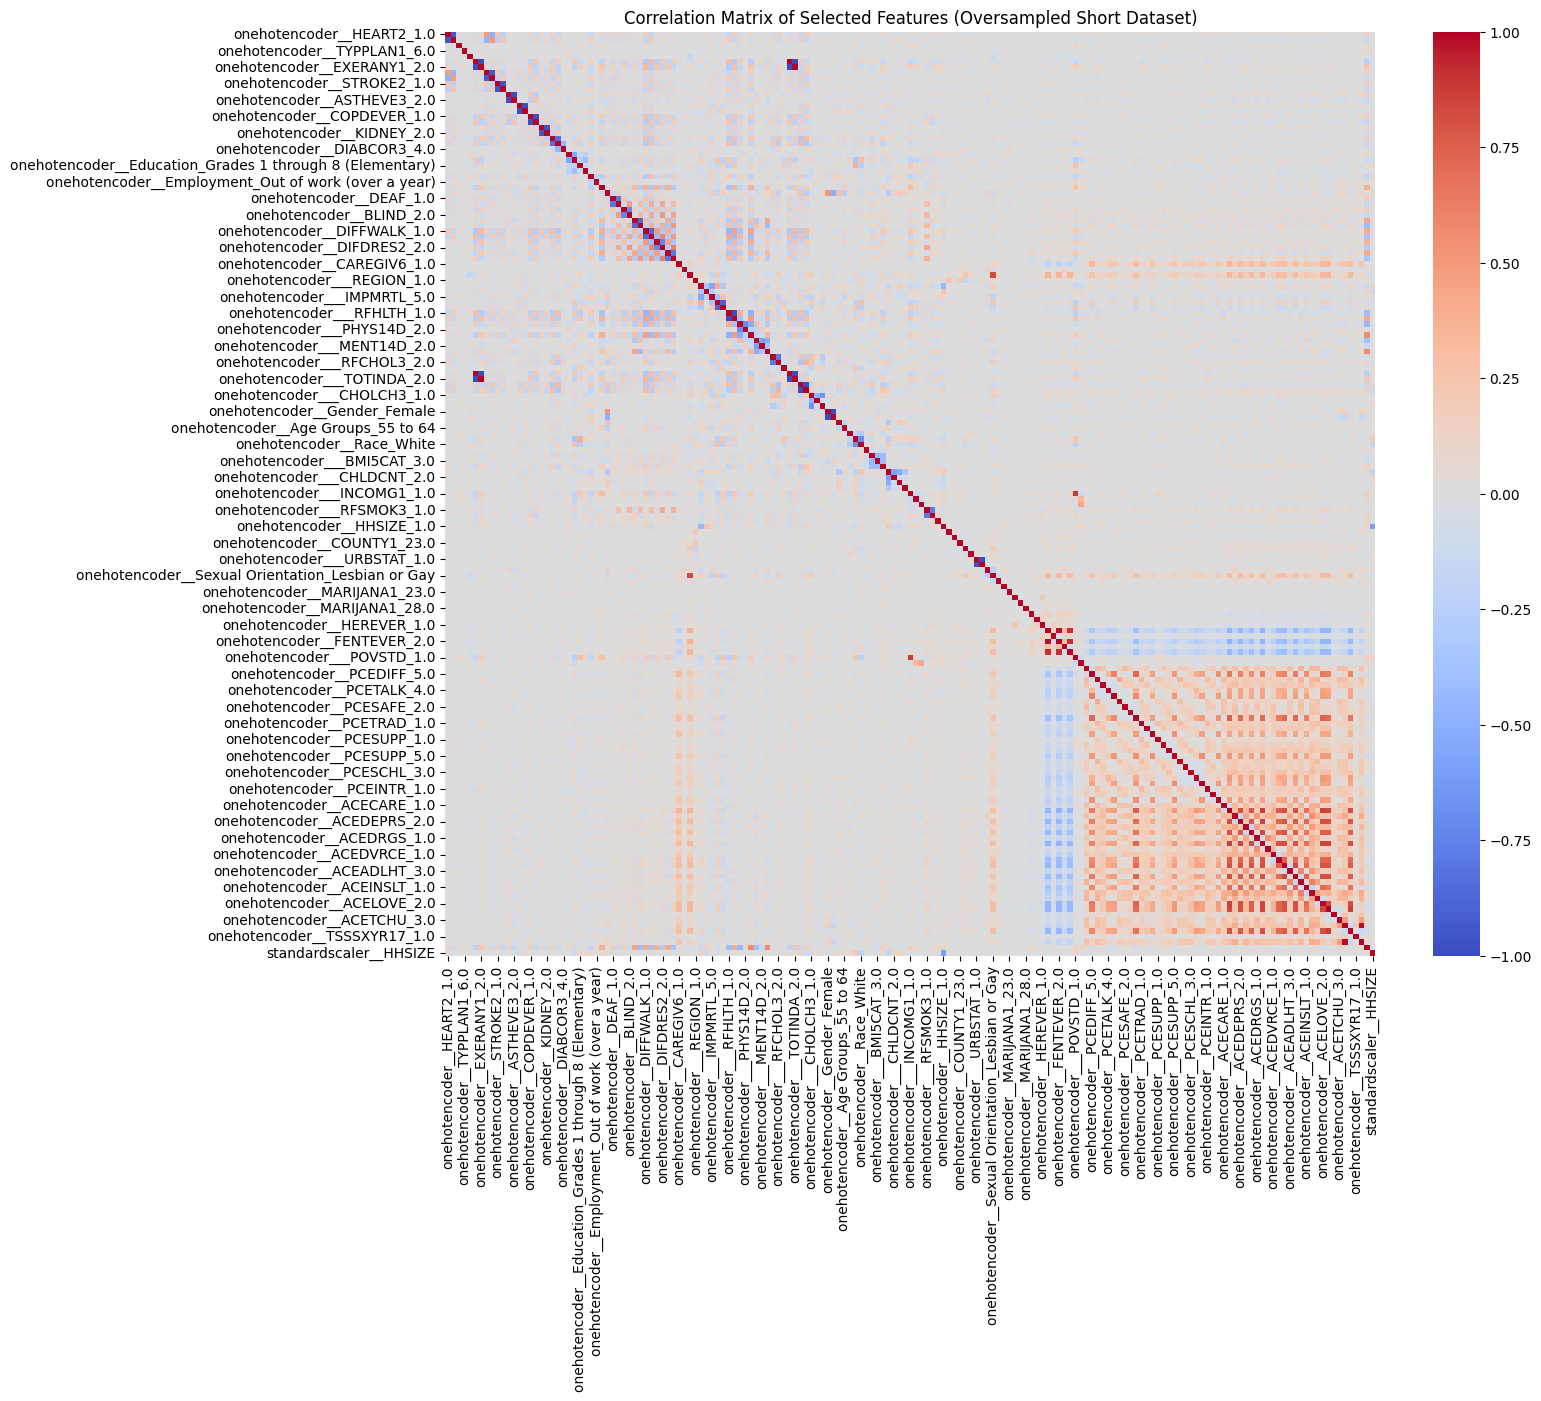

In [41]:
import pandas as pd
import numpy as np

# Convert the sparse matrix to a dense NumPy array
XR_dense = XR_further_reduced.toarray()

# Convert the dense NumPy array to a pandas DataFrame for easy correlation calculation
try:
    # Use feature_names_further_reduced_XR which corresponds to the columns in X_train
    XR_df = pd.DataFrame(XR_dense, columns=feature_names_further_reduced_XR)
except NameError:
    print("Warning: feature_names_further_reduced_XR not found. Using generic column names.")
    XR_df = pd.DataFrame(XR_dense)


# Calculate the correlation matrix
Corr_Matrix = XR_df.corr()

# Round the correlation matrix for display
Corr_Matrix_rounded = round(Corr_Matrix, 2)

# You can optionally visualize the correlation matrix using seaborn heatmap if it's not too large
# import seaborn as sns
# import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))
sns.heatmap(Corr_Matrix_rounded, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of Selected Features (Oversampled Short Dataset)')
plt.show()

In [42]:
# This part is checking for strang relationships between the variables. One would expect that all the characteristics in one variable are highly correlated.
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Convert the sparse matrix X to a dense NumPy array
X_dense = XR_further_reduced.toarray()

vif_data = pd.DataFrame()
# Use the feature names corresponding to the columns in X for the DataFrame
vif_data["feature"] = feature_names_further_reduced_XR

# Calculate VIF for each feature using the dense array
vif_data["VIF"] = [variance_inflation_factor(X_dense, i)
                          for i in range(X_dense.shape[1])]

vif_data.sort_values(by='VIF', ascending=False)

,feature,VIF
6,onehotencoder__EXERANY1_2.0,inf
5,onehotencoder__EXERANY1_1.0,inf
62,onehotencoder___TOTINDA_1.0,inf
97,onehotencoder___URBSTAT_2.0,inf
96,onehotencoder___URBSTAT_1.0,inf
...,...,...
92,onehotencoder__COUNTY1_19.0,1.049012
102,onehotencoder__MARIJANA1_23.0,1.046771
101,onehotencoder__MARIJANA1_21.0,1.039372
105,onehotencoder__MARIJANA1_28.0,1.031500


**5. Excluding Variables where VIF = 'inf' or values over 20.**

In [43]:
# List of features with infinite vif/ or >20, we don't want to loose a variable Characteristics and we will keep the "Yes" answer for those.

#infinite_vif_features = vif_data[vif_data['VIF'] == np.inf]['feature'].tolist()
infinite_vif_features20 = vif_data[vif_data['VIF'] > 20]['feature'].tolist()
# List of features the user wants to keep from the infinite VIF list (keeping the 'yes' answer for all variables it wan't me to cut out)
features_to_keep_vif =['onehotencoder__HEART2_1.0',  'onehotencoder__EXERANY1_1.0',  'onehotencoder__STROKE2_1.0',  'onehotencoder__ASTHEVE3_1.0',  'onehotencoder__OTHCANC_1.0',  'onehotencoder__COPDEVER_1.0',  'onehotencoder__KIDNEY_1.0', 'onehotencoder__DEAF_1.0',  'onehotencoder__BLIND_1.0',  'onehotencoder__REMEM2_1.0',  'onehotencoder__DIFFWALK_1.0',
 'onehotencoder__DIFDRES2_1.0',  'onehotencoder__DIFFERND_1.0',  'onehotencoder___RFHLTH_1.0',  'onehotencoder___PHYS14D_1.0',  'onehotencoder___PHYS14D_3.0', 'onehotencoder___MENT14D_1.0', 'onehotencoder___RFCHOL3_1.0',  'onehotencoder___TOTINDA_1.0', 'onehotencoder___RFHYPE6_1.0', 'onehotencoder___RFHYPE6_2.0', 'onehotencoder___CHOLCH3_1.0', 'onehotencoder__Gender_Female', 'onehotencoder__Gender_Male', 'onehotencoder___RFSMOK3_1.0', 'onehotencoder___URBSTAT_1.0',  'onehotencoder__HEREVER_2.0', 'onehotencoder__FENTEVER_2.0', 'onehotencoder__STIMEVER_1.0','onehotencoder__ACECARE_1.0', 'onehotencoder__ACEDEPRS_1.0', 'onehotencoder__ACEALC_1.0', 'onehotencoder__ACEDRGS_1.0', 'onehotencoder__ACEDVRCE_1.0', 'onehotencoder__ACEHTKDS_1.0', 'onehotencoder__ACELOVE_1.0', 'onehotencoder__ACETCHU_1.0', 'onehotencoder__TSSSXEVER_1.0','onehotencoder__TSSSXYR17_1.0']

# Features to drop are all features with non-infinite VIF or VIF >10,
# plus the infinite VIF features that are NOT in the user's keep list
features_to_drop_vif20 = vif_data[vif_data['VIF'] == np.inf]['feature'].tolist() + \
                      [feature for feature in infinite_vif_features20 if feature not in features_to_keep_vif]


# Get the indices of features to keep
features_to_keep_vif_indices = [i for i, feature in enumerate(feature_names_further_reduced_XR) if feature not in features_to_drop_vif20]

# Select the columns to keep from the sparse matrix X
X_reduced_vif20 = XR_further_reduced[:, features_to_keep_vif_indices]

# Update feature_names to reflect the names of the selected features
feature_names_reduced_vif = [feature_names_further_reduced_XR[i] for i in features_to_keep_vif_indices]


print(f"Original number of features in X: {X.shape[1]}")
print(f"Number of features dropped: {len(features_to_drop_vif20)}")
print(f"Number of features after selection: {X_reduced_vif20.shape[1]}")
print(f"Features dropped: {features_to_drop_vif20}")
print(f"Features kept from infinite VIF list: {features_to_keep_vif}")
print(f"Features kept: {feature_names_reduced_vif}")

Original number of features in X: 188
Number of features dropped: 34
Number of features after selection: 138
Features dropped: ['onehotencoder__EXERANY1_1.0', 'onehotencoder__EXERANY1_2.0', 'onehotencoder___TOTINDA_1.0', 'onehotencoder___TOTINDA_2.0', 'onehotencoder__Gender_Female', 'onehotencoder__Gender_Male', 'onehotencoder___URBSTAT_1.0', 'onehotencoder___URBSTAT_2.0', 'onehotencoder__EXERANY1_2.0', 'onehotencoder__ASTHEVE3_2.0', 'onehotencoder__OTHCANC_2.0', 'onehotencoder__COPDEVER_2.0', 'onehotencoder__DEAF_2.0', 'onehotencoder__BLIND_2.0', 'onehotencoder__REMEM2_2.0', 'onehotencoder__DIFFWALK_2.0', 'onehotencoder__DIFDRES2_2.0', 'onehotencoder__DIFFERND_2.0', 'onehotencoder___RFHLTH_2.0', 'onehotencoder___PHYS14D_2.0', 'onehotencoder___MENT14D_2.0', 'onehotencoder___MENT14D_3.0', 'onehotencoder___RFCHOL3_2.0', 'onehotencoder___TOTINDA_2.0', 'onehotencoder___URBSTAT_2.0', 'onehotencoder__STIMEVER_2.0', 'onehotencoder__ACECARE_2.0', 'onehotencoder__ACEDEPRS_2.0', 'onehotencoder__

In [44]:
#Lets check again for the vif values of the kept features

# Convert the sparse matrix gene
X_dense2 = X_reduced_vif20.toarray()

vif_data2 = pd.DataFrame()
# Use the feature names corresponding to the columns for the DataFrame
vif_data2["feature"] = feature_names_reduced_vif

# Calculate VIF for each feature using the dense array
vif_data2["VIF"] = [variance_inflation_factor(X_dense2, i)
                          for i in range(X_dense2.shape[1])]
vif_data2.sort_values(by='VIF', ascending=False)

,feature,VIF
13,onehotencoder__KIDNEY_2.0,397.230698
46,onehotencoder___RFHYPE6_1.0,391.531418
8,onehotencoder__STROKE2_2.0,335.739894
1,onehotencoder__HEART2_2.0,238.195266
6,onehotencoder__ANGINA_2.0,235.068289
...,...,...
80,onehotencoder__MARIJANA1_23.0,1.046085
79,onehotencoder__MARIJANA1_21.0,1.037671
82,onehotencoder__MARIJANA1_25.0,1.030784
83,onehotencoder__MARIJANA1_28.0,1.029895


In [45]:
# Get the names of features to drop based on a vif value of >13
features_to_drop_vif13 = vif_data2[vif_data2['VIF'] > 13]['feature'].tolist()

# Get the indices of features to keep
features_to_keep_vif13 = [i for i, feature in enumerate(feature_names_reduced_vif) if feature not in features_to_drop_vif13]

# Select the columns to keep from the sparse matrix X_reduced_vif22
X_reduced_vif13 = X_reduced_vif20[:, features_to_keep_vif13]

# Update feature_names to reflect the names of the selected features
feature_names_reduced_vif13 = [feature_names_reduced_vif[i] for i in features_to_keep_vif13]

print(f"Original number of features in X_reduced_vif22: {X_reduced_vif20.shape[1]}")
print(f"Number of features dropped: {len(features_to_drop_vif13)}")
print(f"Number of features after selection: {X_reduced_vif13.shape[1]}")
print(f"Features dropped: {features_to_drop_vif13}")
print(f"Features kept: {feature_names_reduced_vif13}")

Original number of features in X_reduced_vif22: 138
Number of features dropped: 20
Number of features after selection: 118
Features dropped: ['onehotencoder__HEART2_2.0', 'onehotencoder__ANGINA_2.0', 'onehotencoder__STROKE2_2.0', 'onehotencoder__KIDNEY_1.0', 'onehotencoder__KIDNEY_2.0', 'onehotencoder__DIABCOR3_1.0', 'onehotencoder__DIABCOR3_3.0', 'onehotencoder__Education_College 4 years or more', 'onehotencoder__TRNSGNDR_4.0', 'onehotencoder___IMPHOME_1.0', 'onehotencoder___RFHYPE6_1.0', 'onehotencoder___RFHYPE6_2.0', 'onehotencoder___CHOLCH3_1.0', 'onehotencoder___CHLDCNT_1.0', 'onehotencoder___RFSMOK3_1.0', 'onehotencoder__Sexual Orientation_Lesbian or Gay', 'onehotencoder__HEREVER_2.0', 'onehotencoder__FENTEVER_2.0', 'onehotencoder__ACEHTKDS_1.0', 'onehotencoder__ACETCHU_1.0']
Features kept: ['onehotencoder__HEART2_1.0', 'onehotencoder__TYPPLAN1_10.0', 'onehotencoder__TYPPLAN1_6.0', 'onehotencoder__TYPPLAN1_7.0', 'onehotencoder__ANGINA_1.0', 'onehotencoder__STROKE2_1.0', 'onehoten

**For now we let the program erase Gender, as there is a know difference between females and males and we wan't to look for general features that influence Depression. Later I will look at differences by gender by separating the dataset**.

### **Splitting the Dataset as Train and Test Sets**

In [46]:
#Include sample_weight in the split
X_train, X_test, y_train, y_test, survey_weights_train, survey_weights_test = train_test_split(X_reduced_vif13, yR, survey_weights, test_size=0.3, random_state=42)

In [47]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 141255 stored elements and shape (7904, 118)>

## **Basic model for Predictions**

In [48]:
dummy_clf = DummyClassifier(strategy = 'most_frequent')
dummy_clf.fit(X_train, y_train)

DummyClassifier(strategy='most_frequent')

In [49]:
baseline_accuracy = dummy_clf.score(X_test, y_test)
Accuracy ="{:.2f}%".format(baseline_accuracy * 100)
print("Baseline Accuracy (FULL): ", Accuracy)


Baseline Accuracy (FULL):  49.68%


## **Running LogisticRegression on the Dataset**

In [50]:
LogR1 = LogisticRegressionCV()
LogR1.fit(X_train, y_train)

LogR1_accuracy = LogR1.score(X_train, y_train, sample_weight = survey_weights_train)
accuracy ="{:.2f}%".format(LogR1_accuracy * 100)

# Get predictions on the test set
preds = LogR1.predict(X_test)

precisiona = precision_score(y_test, preds, pos_label=1)
precision = precisiona*100
recalla = recall_score(y_test, preds, pos_label=1)
recall = recalla*100
print("LogR1 Training Accuracy FULL: ", accuracy)
print(f'Precision: {precision:.2f}%')
print(f'Recall: {recall:.2f}%')

LogR1 Training Accuracy FULL:  76.58%
Precision: 76.28%
Recall: 76.83%


In [51]:
# Select features using the training set only (feature selection does not allow to include sample weights)
selector = SelectKBest(k=20)
X_train_selected = selector.fit_transform(X_train, y_train)

# Get the names of the selected features
selected_feature_indices = selector.get_support(indices=True)

# fit again a simple logistic regression on the selected features using the sample weighta for the trainig set
LogR1 = LogisticRegressionCV()
LogR1.fit(X_train_selected, y_train, sample_weight=survey_weights_train) # Train on selected features

# select the same features on the test set, predict, and get the test accuracy:
X_test_selected = selector.transform(X_test)
y_pred = LogR1.predict(X_test_selected) # Predict on selected test features
accuracy= accuracy_score(y_test, y_pred)
x_labels = [feature_names_reduced_vif13[i] for i in selector.get_support(indices=True)]


accuracy2 ="{:.2f}%".format(accuracy * 100)
print("LogR1 Test Accuracy FULL: ", accuracy2)

LogR1 Test Accuracy FULL:  60.18%


In [52]:
#Lets check the coeficients
Cs = np.logspace(-5, .5)


coef_list1 = []
for C in Cs:
    lgr = LogisticRegression(C = C, penalty = 'l2', solver = 'liblinear', random_state = 42, max_iter = 1000)
    lgr.fit(X_train, y_train, sample_weight=survey_weights_train)
    coef_list1.append(lgr.coef_[0])

print(f"Length of coef_list1[0]: {len(coef_list1[0])}")


Length of coef_list1[0]: 118


In [53]:
coef_df = pd.DataFrame(coef_list1, index=Cs)
coef_df.columns = feature_names_reduced_vif13
coef_df.head()

,onehotencoder__HEART2_1.0,onehotencoder__TYPPLAN1_10.0,onehotencoder__TYPPLAN1_6.0,onehotencoder__TYPPLAN1_7.0,onehotencoder__ANGINA_1.0,onehotencoder__STROKE2_1.0,onehotencoder__ASTHEVE3_1.0,onehotencoder__OTHCANC_1.0,onehotencoder__COPDEVER_1.0,onehotencoder__DIABCOR3_4.0,...,onehotencoder__ACEHTKDS_3.0,onehotencoder__ACEINSLT_1.0,onehotencoder__ACEINSLT_3.0,onehotencoder__ACELOVE_1.0,onehotencoder__ACETCHU_2.0,onehotencoder__ACETCHU_3.0,onehotencoder__TSSSXEVER_1.0,onehotencoder__TSSSXYR17_1.0,standardscaler__POORHLTH,standardscaler__HHSIZE
0.000010,-0.148931,-0.097875,-0.043394,-0.151706,-0.082059,-0.087414,-0.200098,-0.004695,-0.058610,-0.239707,...,-0.136095,0.195880,-0.153724,-0.232461,0.175863,-0.183606,-0.314282,-0.082672,-0.282899,0.069433
0.000013,-0.168752,-0.117204,-0.055104,-0.171533,-0.089952,-0.103964,-0.205614,-0.010414,-0.060924,-0.271333,...,-0.148262,0.195338,-0.160167,-0.250295,0.217837,-0.203723,-0.343523,-0.105617,-0.281797,0.074858
0.000017,-0.187983,-0.136927,-0.069691,-0.191279,-0.096820,-0.121662,-0.210055,-0.016861,-0.062699,-0.302364,...,-0.161030,0.192130,-0.167971,-0.267315,0.264018,-0.223142,-0.372831,-0.134119,-0.280989,0.080077
0.000022,-0.206192,-0.156322,-0.088040,-0.210258,-0.102692,-0.140128,-0.213755,-0.023700,-0.063940,-0.331724,...,-0.174075,0.186220,-0.177705,-0.283085,0.313408,-0.241184,-0.401749,-0.169531,-0.280363,0.085096
0.000028,-0.222964,-0.174873,-0.110902,-0.228024,-0.107615,-0.158943,-0.217037,-0.030726,-0.064437,-0.358957,...,-0.187110,0.177879,-0.189650,-0.297532,0.365053,-0.257404,-0.430071,-0.212887,-0.279922,0.089897


## **Testing of Models**

In [54]:
# Initialize the results DataFrame to collect each Model's performance measures
results = pd.DataFrame(columns = ['Model', 'Train Accuracy', 'Test Accuracy', 'Precission', 'Recall', 'Best Parameters'])
from sklearn.ensemble import BaggingClassifier

In [55]:
# Create Model library for analysis
model = {'Logistic Regression': LogisticRegression(),
         'Bgg' : BaggingClassifier(random_state=42),
         'Decision Tree': DecisionTreeClassifier(),
         'SVM': SVC(),
         'RFC': RandomForestClassifier(),
         'XGB': XGBClassifier()}

In [56]:
# Re-encode target variable to be 0-indexed
y_train_encoded = np.where(y_train == 1.0, 0, 1)
y_test_encoded = np.where(y_test == 1.0, 0, 1)

# create a test loop to run every model on the selected data set
for model_name, current_model in model.items():
    # Train the model (applying sample weights)
    current_model.fit(X_train_selected, y_train_encoded, sample_weight=survey_weights_train)

    # Calculate the accuracy
    train_accuracy = current_model.score(X_train_selected, y_train_encoded, sample_weight=survey_weights_train)
    test_accuracy = current_model.score(X_test_selected, y_test_encoded, sample_weight= survey_weights_test)

    best_params = current_model.get_params()

    # Model predictions
    y_pred = current_model.predict(X_test_selected)

    # Calculate precision and recall
    # Need to adjust pos_label for the encoded target variable
    precision = precision_score(y_test_encoded, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test_encoded, y_pred, pos_label=1, zero_division=0)


    # Create a temporary DataFrame for the current model and row
    new_row = pd.DataFrame([{
        'Model': model_name,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy,
        'Precission': precision,
        'Recall': recall,
        "Best Parameters": best_params
    }])

    # Use pd.concat to add the new row to the results DataFrame
    results = pd.concat([results, new_row], ignore_index=True)

In [57]:
results.head(12)

,Model,Train Accuracy,Test Accuracy,Precission,Recall,Best Parameters
0,Logistic Regression,0.860481,0.862815,0.560243,0.973607,"{'C': 1.0, 'class_weight': None, 'dual': False..."
1,Bgg,0.937050,0.843989,0.851872,0.907331,"{'bootstrap': True, 'bootstrap_features': Fals..."
2,Decision Tree,0.945025,0.843153,0.816273,0.912023,"{'ccp_alpha': 0.0, 'class_weight': None, 'crit..."
3,SVM,0.940310,0.844236,0.722172,0.928446,"{'C': 1.0, 'break_ties': False, 'cache_size': ..."
4,RFC,0.944131,0.863685,0.865794,0.930792,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
5,XGB,0.939555,0.845981,0.827160,0.943109,"{'objective': 'binary:logistic', 'base_score':..."


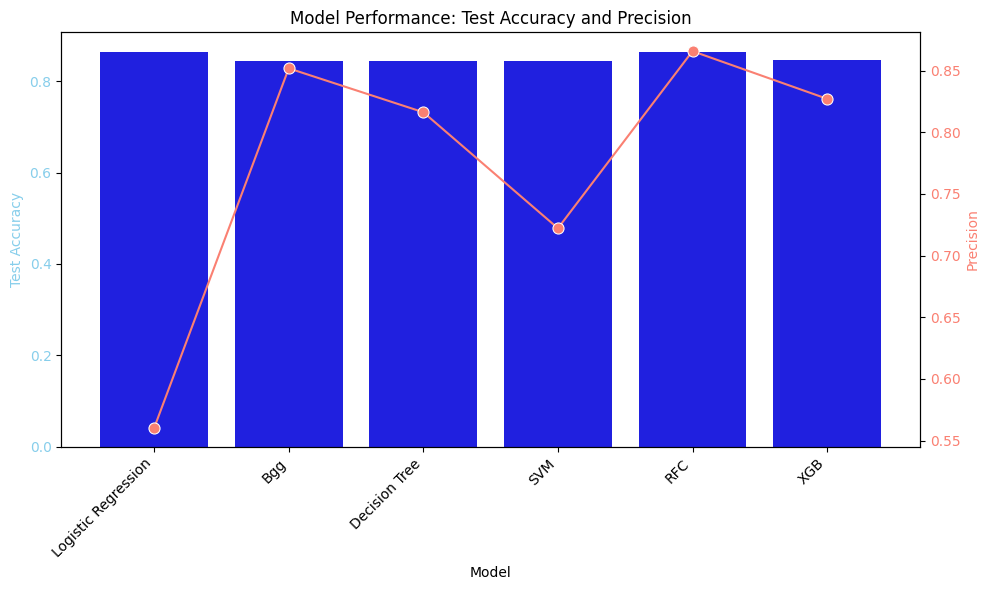

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Test Accuracy on the primary y-axis
sns.barplot(x='Model', y='Test Accuracy', data=results, ax=ax1, color='blue')
ax1.set_ylabel('Test Accuracy', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_title('Model Performance: Test Accuracy and Precision')

# Create a secondary y-axis
ax2 = ax1.twinx()

# Plot Precision on the secondary y-axis
sns.lineplot(x='Model', y='Precission', data=results, ax=ax2, color='salmon', marker='o', markersize=8)
ax2.set_ylabel('Precision', color='salmon')
ax2.tick_params(axis='y', labelcolor='salmon')

# Rotate x-axis labels for better readability
ax1.set_xticklabels(results['Model'], rotation=45, ha='right')

# Show the plot
plt.tight_layout()
plt.show()

In [59]:
# Look at the classification report
from sklearn.metrics import classification_report

print(classification_report(y_test_encoded, y_pred, target_names=['Yes', 'No']))

              precision    recall  f1-score   support

         Yes       0.93      0.80      0.86      1683
          No       0.83      0.94      0.88      1705

    accuracy                           0.87      3388
   macro avg       0.88      0.87      0.87      3388
weighted avg       0.88      0.87      0.87      3388



**Calculating Feature Importance for RandomForestClassifier to narrow the list down**

In [60]:
RFCopt = RandomForestClassifier(bootstrap = True, ccp_alpha= 0.0, criterion= 'gini', max_depth= None, max_features= 'sqrt', min_samples_leaf = 1, min_samples_split=  2, n_estimators= 100, n_jobs= None, oob_score= False, random_state= None, verbose= 0, warm_start= False)
RFCopt.fit(X_train, y_train, sample_weight = survey_weights_train)
# Get feature importances
importancesRFCopt = RFCopt.feature_importances_

# Select the indices of features with importance greater than a threshold
threshold = 0.005 # Adjust as needed
selected_feature_indices_rfc = np.where(importancesRFCopt > threshold)[0]


# Use the selected indices to get the names of the selected features
# based on the columns that went into X_train
if 'feature_names_reduced_vif13' in globals():
    selected_feature_names_rfc = [feature_names_reduced_vif13[i] for i in selected_feature_indices_rfc]
else:
    print("Warning: feature_names_reduced_vif13 not found. Cannot get feature names.")
    selected_feature_names_rfc = [f"Feature_{i}" for i in selected_feature_indices_rfc] # Fallback


# Select columns from the sparse matrices using the selected indices
X_train_selected_rfc = X_train[:, selected_feature_indices_rfc]
X_test_selected_rfc = X_test[:, selected_feature_indices_rfc]


print(f"Original number of features in X_train: {X_train.shape[1]}")
print(f"Number of features selected: {X_train_selected_rfc.shape[1]}")
print(f"Selected feature names: {selected_feature_names_rfc}")

Original number of features in X_train: 118
Number of features selected: 69
Selected feature names: ['onehotencoder__HEART2_1.0', 'onehotencoder__TYPPLAN1_10.0', 'onehotencoder__TYPPLAN1_7.0', 'onehotencoder__ANGINA_1.0', 'onehotencoder__ASTHEVE3_1.0', 'onehotencoder__OTHCANC_1.0', 'onehotencoder__COPDEVER_1.0', 'onehotencoder__DIABCOR3_4.0', 'onehotencoder__Education_College 1 year to 3 years', 'onehotencoder__Education_Some college or technical school', 'onehotencoder__Employment_Employed for Wages', 'onehotencoder__Employment_Out of work (over a year)', 'onehotencoder__Employment_Unable to work', 'onehotencoder__PREGNANT_2.0', 'onehotencoder__DEAF_1.0', 'onehotencoder__BLIND_1.0', 'onehotencoder__REMEM2_1.0', 'onehotencoder__DIFFWALK_1.0', 'onehotencoder__DIFFERND_1.0', 'onehotencoder__CAREGIV6_1.0', 'onehotencoder___REGION_1.0', 'onehotencoder___IMPMRTL_1.0', 'onehotencoder___IMPMRTL_2.0', 'onehotencoder___IMPMRTL_5.0', 'onehotencoder___IMPHOME_2.0', 'onehotencoder___RFHLTH_1.0', '

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


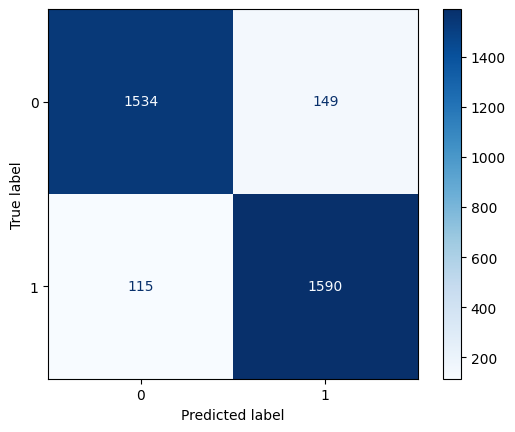

In [61]:
#Testing the Model with the selected features

RFCopt = RandomForestClassifier(bootstrap = True, ccp_alpha= 0.0, criterion= 'gini', max_depth= None, max_features= 'sqrt', min_samples_leaf = 1, min_samples_split=  2, n_estimators= 100, n_jobs= None, oob_score= False, random_state= None, verbose= 0, warm_start= False)
RFCopt.fit(X_train_selected_rfc, y_train_encoded, sample_weight=survey_weights_train)

train_accuracy2 = RFCopt.score(X_train_selected_rfc, y_train_encoded, sample_weight=survey_weights_train)
test_accuracy2 = RFCopt.score(X_test_selected_rfc, y_test_encoded, sample_weight= survey_weights_test)

best_params2 = RFCopt.get_params()

# Model predictions
y_pred2 = RFCopt.predict(X_test_selected_rfc)


# Calculate precision and recall
# Need to adjust pos_label for the encoded target variable
precision2 = precision_score(y_test_encoded, y_pred2, pos_label=0, zero_division=0)
recall2 = recall_score(y_test_encoded, y_pred2, pos_label=0, zero_division=0)

ConfusionMatrixDisplay.from_estimator(RFCopt, X_test_selected_rfc, y_test_encoded, cmap='Blues')
print(best_params2)

Run **XGBClassifier** for comparrison and to display shap values.


Dtype of X_test_selected_rfc before conversion: float64
Dtype of X_test_selected_rfc_dense after conversion: float64
Length of selected_feature_names_rfc: 69


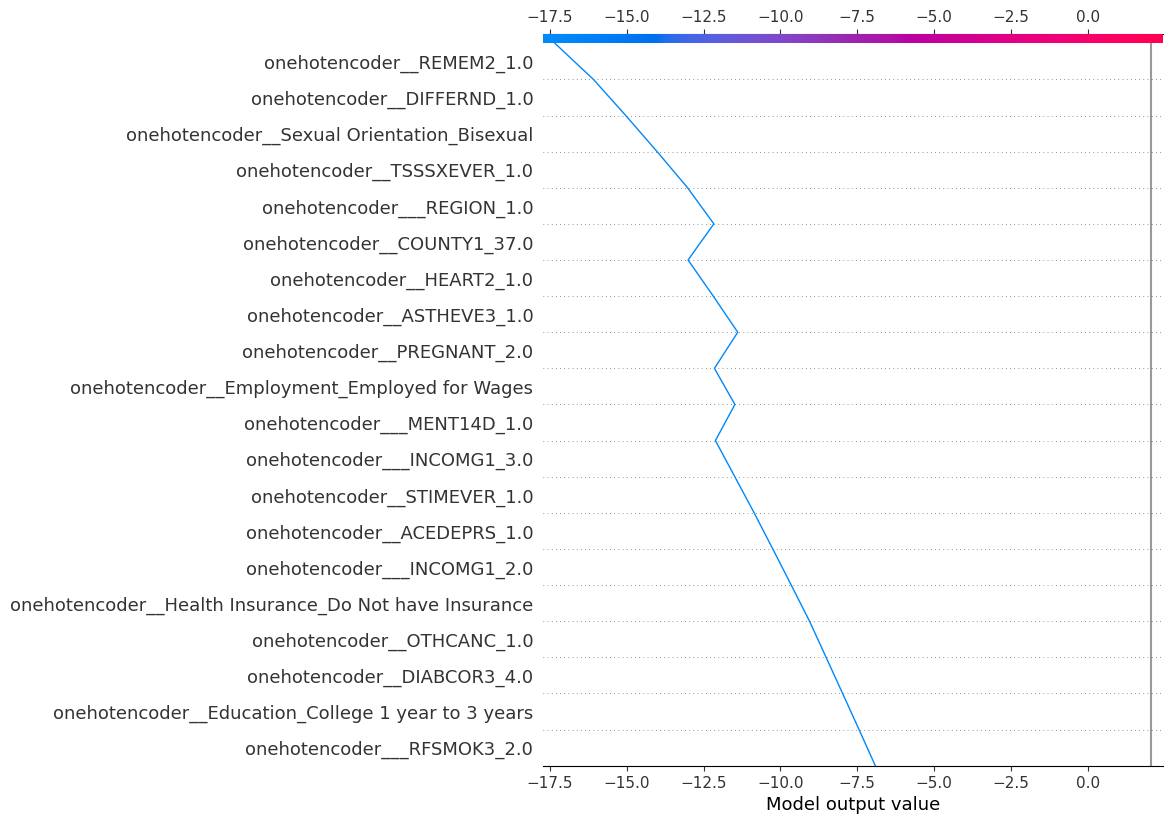

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


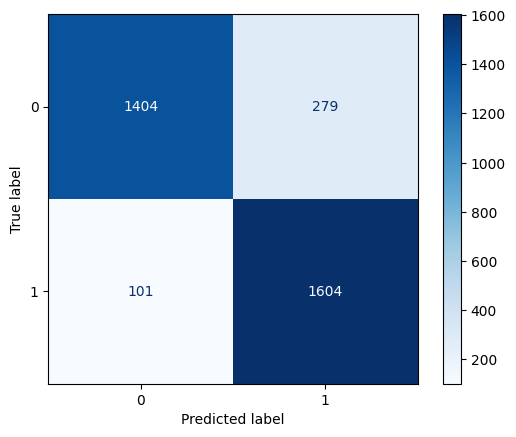

In [62]:
import graphviz
from sklearn.tree import export_graphviz
import shap
import numpy as np # Ensure numpy is imported
from xgboost import XGBClassifier, XGBRegressor

# Re-initialize SHAP JavaScript visualization
shap.initjs()

# It is generally better to use XGBClassifier for classification tasks
xgb1 = XGBClassifier(n_estimators = 100, random_state= 42)


xgb1.fit(X_train_selected_rfc, y_train_encoded, sample_weight=survey_weights_train)


train_accuracy_xgb1 = xgb1.score(X_train_selected_rfc, y_train_encoded, sample_weight=survey_weights_train)
test_accuracy_xgb1 = xgb1.score(X_test_selected_rfc, y_test_encoded, sample_weight= survey_weights_test)

best_params_xgb1 = xgb1.get_params()

# Model predictions
y_pred2 = xgb1.predict(X_test_selected_rfc)


# Calculate precision and recall
# Need to adjust pos_label for the encoded target variable
precision2 = precision_score(y_test_encoded, y_pred2, pos_label=0, zero_division=0)
recall2 = recall_score(y_test_encoded, y_pred2, pos_label=0, zero_division=0)


# Initialize the SHAP explainer with the fitted xgb1 model
explainer = shap.TreeExplainer(xgb1)

# Print dtype before conversion
print(f"Dtype of X_test_selected_rfc before conversion: {X_test_selected_rfc.dtype}")

# Convert the sparse test data to a dense array with a numeric dtype
X_test_selected_rfc_dense = X_test_selected_rfc.toarray().astype(np.float64)

# Print dtype after conversion
print(f"Dtype of X_test_selected_rfc_dense after conversion: {X_test_selected_rfc_dense.dtype}")

# Calculate SHAP values on the dense test data
shap_values = explainer.shap_values(X_test_selected_rfc_dense)

# Verify the shapes before plotting

print(f"Length of selected_feature_names_rfc: {len(selected_feature_names_rfc)}")


# Select a feature name to plot dependence for.
feature_to_plot_name = selected_feature_names_rfc[0]

# Find the index of this feature in the selected feature names
feature_to_plot_index = selected_feature_names_rfc.index(feature_to_plot_name)


shap.decision_plot(
    explainer.expected_value, # Use the expected value directly
    shap_values[0], # Use SHAP values for the 'Depression' class (encoded as 0)
    feature_names=selected_feature_names_rfc
)


ConfusionMatrixDisplay.from_estimator(xgb1, X_test_selected_rfc, y_test_encoded, cmap='Blues')
print(best_params2)

In [63]:
from scipy import stats
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_val_score, cross_val_predict # Import KFold, RandomizedSearchCV, cross_val_score, and cross_val_predict
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import roc_auc_score # Import roc_auc_score

clf_xgb = xgb.XGBClassifier(objective = 'binary:logistic')
param_dist = {'n_estimators': stats.randint(150, 1000),
              'learning_rate': stats.uniform(0.01, 0.59),
              'subsample': stats.uniform(0.3, 0.6),
              'max_depth': [3, 4, 5, 6, 7, 8, 9],
              'colsample_bytree': stats.uniform(0.5, 0.4),
              'min_child_weight': [1, 2, 3, 4],
              'learning_rate': stats.uniform(0.01, 0.59),
              'gamma': stats.uniform(0, 0.5)
             }

numFolds = 5
folds = KFold(n_splits = numFolds, shuffle = True) # Use KFold

clf = RandomizedSearchCV(clf_xgb,
                         param_distributions = param_dist,
                         cv = folds, # Use the KFold object for cv
                         n_iter = 5,
                         scoring = 'roc_auc',
                         error_score = 0,
                         verbose = 3,
                         n_jobs = -1)

# Re-encode target variable to be 0-indexed for XGBoost
yR_encoded = np.where(yR == 1.0, 0, 1)

# Fit RandomizedSearchCV using the re-encoded target variable and sample weights
# Assuming X_train_selected_rfc, y_train_encoded, and survey_weights_train are defined from previous cells
clf.fit(X_train_selected_rfc, y_train_encoded, sample_weight=survey_weights_train)

# After fitting, you can access the best estimator
best_estimator = clf.best_estimator_

# Now you can use cross_val_score or cross_val_predict with the best estimator
# Example using cross_val_score:
# Note: cross_val_score can also take sample_weight
cv_scores = cross_val_score(best_estimator, X_train_selected_rfc, y_train_encoded, cv=folds, scoring='roc_auc')

print("Cross-validation ROC AUC scores:", cv_scores)
print("Mean Cross-validation ROC AUC score:", np.mean(cv_scores))

# Example using cross_val_predict:
cv_predictions = cross_val_predict(best_estimator, X_train_selected_rfc, y_train_encoded, cv=folds)

# You can also evaluate the best estimator on the test set
# Assuming X_test_selected_rfc and y_test_encoded are defined from previous cells
test_roc_auc = roc_auc_score(y_test_encoded, best_estimator.predict_proba(X_test_selected_rfc)[:, 1])

print("Test Set ROC AUC score:", test_roc_auc)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Cross-validation ROC AUC scores: [0.96063203 0.95927938 0.96089204 0.96094795 0.95606146]
Mean Cross-validation ROC AUC score: 0.9595625701975482
Test Set ROC AUC score: 0.9588238779027117


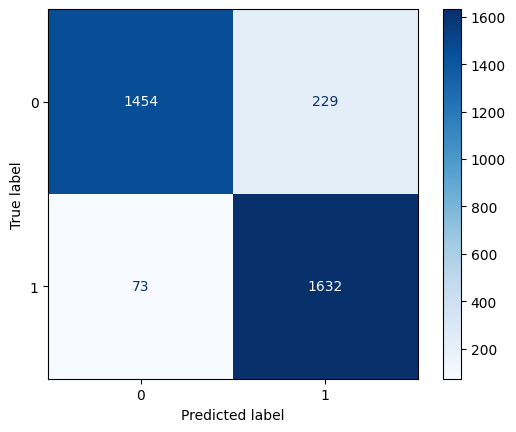

In [64]:
ConfusionMatrixDisplay.from_estimator(best_estimator, X_test_selected_rfc, y_test_encoded, cmap='Blues')

Attempting to plot shap_values[0] failed with AssertionError: Summary plots need a matrix of shap_values, not a vector.
Trying to plot the raw shap_values list (if applicable for this explainer type).


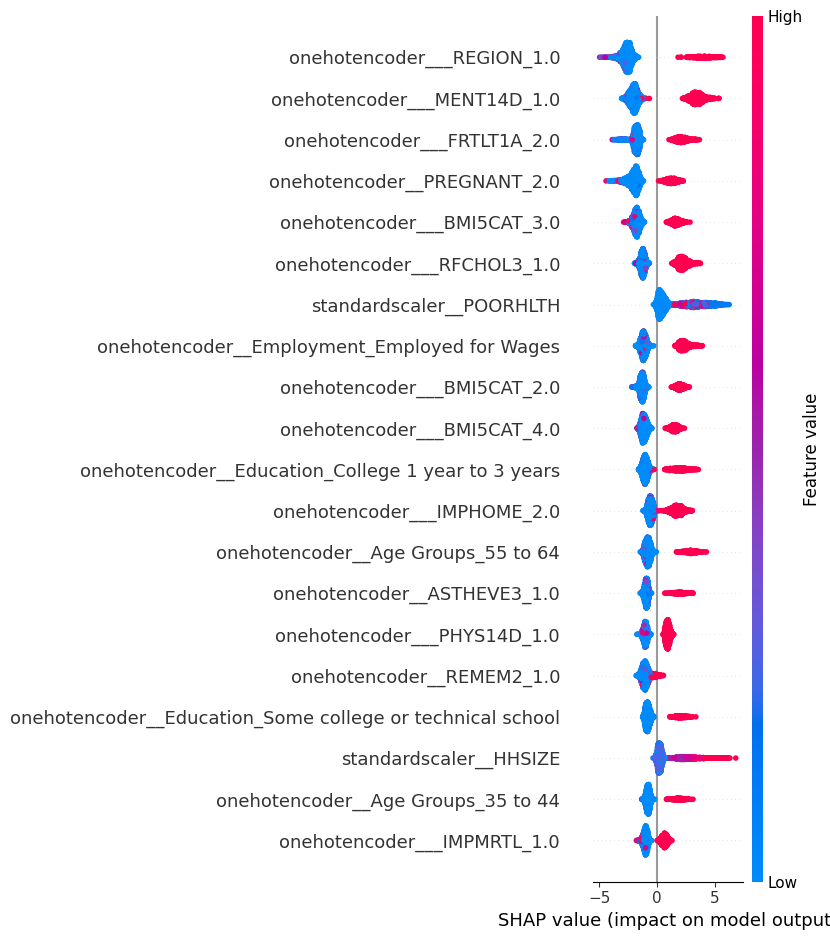

In [65]:
import shap

# Calculate SHAP values
explainer = shap.TreeExplainer(best_estimator) # Using the best_estimator from RandomizedSearchCV
shap_values = explainer.shap_values(X_test_selected_rfc_dense)

# For binary classification, shap_values is typically a list of two arrays.
# shap.summary_plot can often handle this list directly.

# Plot summary plot for the positive class (index 0)
# Pass the SHAP values for the class as a matrix.

try:
    shap.summary_plot(
        shap_values[0], # Pass the SHAP values for the first class
        features=X_test_selected_rfc_dense, # Pass the feature values (samples x features)
        feature_names=selected_feature_names_rfc, # Use the feature names from the selected features
        plot_type="dot" # Default plot type
    )
except AssertionError as e:
    print(f"Attempting to plot shap_values[0] failed with AssertionError: {e}")
    print("Trying to plot the raw shap_values list (if applicable for this explainer type).")
    # If plotting shap_values[0] fails, try plotting the raw list.
    # This might work if summary_plot handles the multi-output structure.
    try:
        shap.summary_plot(
            shap_values, # Pass the raw shap_values list
            features=X_test_selected_rfc_dense, # Pass the feature values (samples x features)
            feature_names=selected_feature_names_rfc, # Use the feature names from the selected features
            plot_type="dot", # Default plot type
            class_names=['Depression', 'No Depression'] # Provide class names for clarity
        )
    except Exception as inner_e:
        print(f"Plotting raw shap_values list failed with: {inner_e}")
        print("Diagnosing further...")
        # If both fail, print the shape of shap_values and its elements for diagnosis.
        print(f"Shape of shap_values: {np.array(shap_values).shape}")
        if isinstance(shap_values, list):
            for i, sv in enumerate(shap_values):
                print(f"Shape of shap_values[{i}]: {sv.shape}")
        print(f"Shape of features (X_test_selected_rfc_dense): {X_test_selected_rfc_dense.shape}")

## Interpretation of Model Results

BSummary

This project aimed to build a model to predict depression using the Behavioral Risk Factor Surveillance System (BRFSS) 2021 dataset.

Key Steps:

**Data Loading and Selection:**
 Loaded the SAS dataset and selected relevant variables based on potential association with mental health outcomes.
**Data Cleaning and Preprocessing:**
 Handled missing values and unknown responses by replacing them with -1. Recoded several categorical variables for better interpretability. Sub-selected the target variable to only include Yes and No responses.
**Feature Engineering and Selection:**
 Separated categorical and numerical features. Applied One-Hot Encoding and StandardScaler. Performed initial feature screening based on correlation with the target variable. Oversampled the minority class (Depression) using SMOTE to address class imbalance. Further reduced features by removing those with high Variance Inflation Factor (VIF) to address multicollinearity.
**Model Training and Evaluation:**
 Trained several classification models including Logistic Regression, Bagging Classifier, Decision Tree, SVM, RandomForestClassifier, and XGBoost Classifier. Evaluated models based on training and testing accuracy, precision, and recall. Used Feature Importance from RandomForestClassifier to identify a subset of important features. Performed hyperparameter tuning on the XGBoost classifier using RandomizedSearchCV with cross-validation and evaluated its performance using ROC AUC score and a confusion matrix. Other models were tested including tensorflow, but tested unsatifactory and were excluded fromt this notebook.

#**Interpretation of Model Results**

**Based on the SHAP summary plot and the confusion matrix from the Best XGBoost Estimator:**

The color of the dots shows the feature value (red for high, blue for low), allowing us to see how feature values relate to their impact on the prediction.
Confusion Matrix Interpretation:

The confusion matrix provides a breakdown of the  XGBClassifier model's predictions on the test set:

*   **True Positives (bottom right, 1632/95.7%):** Correctly predicted instances of Depression (0).
*   **True Negatives (top left, 1454/86.4%):** Correctly predicted instances of No Depression (1).
*   **False Positives (top right, 229/13.6%):** Instances predicted as Depression (0) but are actually No Depression (1) (Type I error).
*   **False Negatives (bottom left 73/4.3%):** Instances predicted as No Depression (1) but are actually Depression (0) (Type II error).


Analyzing these values helps assess the model's accuracy, precision, and recall for each class. For depression prediction, a high recall for the positive class (Depression) is often crucial to minimize false negatives (missing actual cases of depression). The balance between precision and recall depends on the specific goals of the model.

The model shows promising performance in identifying instances of diagnosed Depression.
It has a high rate of correctly identifying individuals with Depression (True Positives).
The False Negative rate (missing actual cases of depression) is relatively low, which is important for this type of prediction.
The False Positive rate (predicting depression when it's not present) is higher, which is a trade-off to consider depending on the application.
**The Test Set ROC AUC score of 95.9%** indicates good discriminatory power.

**Important Variables (Based on SHAP):**

The SHAP summary plot reveals the features that have the most significant impact on the model's prediction of depression. The features are ranked by their average absolute SHAP value, indicating their overall importance across the dataset.

Features with high SHAP values (dots to the right) push the prediction towards the positive class (Depression).
Features with low SHAP values (dots to the left) push the prediction towards the negative class (No Depression).

For example:

*  Mental health (e.g., number of days mental health was not good)
*  Certain chronic conditions (e.g., diabetes, high cholesterol, heart conditions)
*  Socio-economic factors (e.g., employment)
*  Experiences of adverse childhood events (ACEs)

It is important to mention, the included measures are associtated with Depression, but they are not predictive in a sense that they can lead to Depression instead of being the result (high BMI).

#**Limitations:**

**Target Viariable:** The outcome variable is "Where you ever (by a health provider) diagnosed with a Depression?"
By definition that reduces the outcome to people with access to healthcare, and includes individuals that don't currently experience any Depression. Both factors influence model performance and predictability.

**Causation vs. Association:** The identified important variables are associated with depression in this dataset, but the model does not imply causation. Further research is needed to understand causal relationships.

**Survey Weights:** While survey weights (_LLCPWT2) were included in model training to account for potential sampling bias, the approach for handling weights with synthetic samples generated by SMOTE (assigning a weight of 1.0) could be further refined. Assigning an average weight of the minority class or using more advanced techniques for handling weights with oversampling might improve results.

**Data Specificity:** The model is trained on the BRFSS 2021 data from a specific region (California). Its generalizability to other populations or years may need further validation.

**Gender Differences:** The analysis excluded gender to look for general influencing factors. Further analysis could explore differences in depression prediction by gender by separating the dataset.